In [ ]:
"""
=============================================================================
FILE    : 01_extract_and_clean.py
PROJECT : Pipeline ETL Otomatis — Segmentasi Merchant Anchor Bank BTN
TAHAP   : EXTRACT & CLEAN (Tahap 1 dari 3)
AUTHOR  : Data Analyst Intern — Digital Banking Sales, Divisi Anchor

DESKRIPSI:
    File ini adalah tahap pertama dari pipeline ETL. Tugasnya adalah:
    1. Membaca 3 file Excel sumber ke dalam SQLite sebagai staging database
    2. Mengekstrak data dari SQLite menggunakan SQL query ke Pandas DataFrame
    3. Membersihkan dan menstandarisasi format data
    4. Mendeteksi & menyamakan nama merchant yang tidak konsisten antar file
       menggunakan RapidFuzz (teknik Fuzzy String Matching)

OUTPUT  : 3 DataFrame bersih yang siap diproses di tahap berikutnya
          - df_master    : Data master semua merchant
          - df_card      : Data finansial bulanan (TRX, SV, FBI)
          - df_monitoring: Data mingguan per merchant per PM

ARGUMEN SIDANG — KENAPA PAKAI SQLite SEBAGAI STAGING?
    "Dalam environment production perbankan, data tidak dibaca langsung dari
    file Excel — melainkan dari database relasional. SQLite digunakan di sini
    untuk mensimulasikan proses tersebut: file Excel diingest ke dalam SQLite
    sebagai staging area, kemudian diekstrak menggunakan SQL query ke Pandas.
    Pendekatan ini memisahkan concern antara penyimpanan data (storage layer)
    dan pemrosesan data (processing layer), sesuai prinsip arsitektur ETL yang
    baik. Kode SQL yang digunakan identik dengan yang dipakai di PostgreSQL
    atau Oracle — hanya layer koneksinya yang berbeda."
=============================================================================
"""

import pandas as pd
import sqlite3
import os
from rapidfuzz import process, fuzz

# =============================================================================
# ARGUMEN SIDANG — KENAPA PAKAI RapidFuzz, BUKAN FuzzyWuzzy?
# =============================================================================
# "FuzzyWuzzy sudah deprecated (tidak aktif dikembangkan sejak 2021).
#  RapidFuzz adalah penerus resminya dengan API yang hampir identik, namun
#  diimplementasikan menggunakan C++ di bawahnya sehingga 10-100x lebih cepat.
#  Untuk dataset dengan ribuan merchant, perbedaan performa ini sangat signifikan.
#  RapidFuzz mengimplementasikan algoritma Levenshtein Distance dan token-based
#  matching, yang akurat untuk menangani variasi penulisan nama merchant seperti
#  singkatan, typo, dan perbedaan spasi."
# =============================================================================


# =============================================================================
# BAGIAN 0 — KONFIGURASI PATH
# =============================================================================

# Path ke file Excel sumber (sesuaikan dengan lokasi file di komputer kamu)
PATH_MASTER   = "C:/Users/Lenovo/Documents/UMN/Semester 6 Magang/Materi Sidang/Project/data/ALL_MID_202601_MASTER.xlsx"
PATH_CARD     = "C:/Users/Lenovo/Documents/UMN/Semester 6 Magang/Materi Sidang/Project/data/CARD_SHARE_MERCHANT_ANCHOR_2026.xlsx"
PATH_MONITOR  = "C:/Users/Lenovo/Documents/UMN/Semester 6 Magang/Materi Sidang/Project/data/Monitoring_Weekly_Anchor_2026.xlsx"

# Path ke database SQLite yang akan dibuat sebagai staging area
PATH_DB = "database/staging_anchor.db"

# Threshold similarity score untuk RapidFuzz matching
# Nilai 85 berarti: jika dua nama memiliki kesamaan >= 85%, dianggap merchant sama
FUZZY_THRESHOLD = 85


# =============================================================================
# BAGIAN 1 — FUNGSI INGEST: Excel → SQLite
# =============================================================================

def ingest_to_sqlite(path_db):
    """
    Membaca ketiga file Excel dan menyimpannya ke dalam SQLite sebagai
    staging database. Proses ini dilakukan sekali di awal pipeline.

    Mengapa data disimpan ke SQLite dulu sebelum diproses?
    → Memisahkan proses 'loading data' dari 'processing data' (prinsip ETL)
    → Memudahkan debugging: data raw tersimpan utuh di database
    → Bisa di-query ulang kapan saja tanpa buka ulang file Excel
    """

    # Buat folder database jika belum ada
    os.makedirs(os.path.dirname(path_db), exist_ok=True)

    # Buka koneksi ke SQLite (file .db akan dibuat otomatis jika belum ada)
    conn = sqlite3.connect(path_db)

    print("=" * 60)
    print("TAHAP 1 — INGEST FILE EXCEL KE SQLite STAGING DATABASE")
    print("=" * 60)

    # ----- TABEL 1: ALL_MID_MASTER -----
    print("\n[1/3] Membaca ALL_MID_MASTER...")
    df_raw_master = pd.read_excel(PATH_MASTER, sheet_name="Sheet1", dtype={"MERCHANT_ID": str})
    # Simpan ke SQLite dengan nama tabel 'raw_master'
    df_raw_master.to_sql("raw_master", conn, if_exists="replace", index=False)
    print(f"      ✓ {len(df_raw_master):,} baris berhasil diingest ke tabel 'raw_master'")

    # ----- TABEL 2: CARD_SHARE (sheet Realisasi = data finansial bulanan) -----
    print("\n[2/3] Membaca CARD_SHARE_MERCHANT — sheet 'Realisasi'...")
    df_raw_card = pd.read_excel(PATH_CARD, sheet_name="Realisasi")
    df_raw_card.to_sql("raw_card_share", conn, if_exists="replace", index=False)
    print(f"      ✓ {len(df_raw_card):,} baris berhasil diingest ke tabel 'raw_card_share'")

    # ----- TABEL 3a: MONITORING 2026 (data aktual mingguan) -----
    print("\n[3/3] Membaca MONITORING_WEEKLY — sheet '2026' dan 'Edit Target'...")
    df_raw_monitor = pd.read_excel(PATH_MONITOR, sheet_name="2026")
    df_raw_monitor.to_sql("raw_monitoring_2026", conn, if_exists="replace", index=False)
    print(f"      ✓ {len(df_raw_monitor):,} baris berhasil diingest ke tabel 'raw_monitoring_2026'")

    # ----- TABEL 3b: TARGET 2026 (dari sheet Edit Target) -----
    df_raw_target = pd.read_excel(PATH_MONITOR, sheet_name="Edit Target")
    df_raw_target.to_sql("raw_target_2026", conn, if_exists="replace", index=False)
    print(f"      ✓ {len(df_raw_target):,} baris berhasil diingest ke tabel 'raw_target_2026'")

    # ----- TABEL 4: SUM per Merchant (ringkasan total) -----
    df_raw_sum = pd.read_excel(PATH_MONITOR, sheet_name="SUM")
    df_raw_sum.to_sql("raw_sum_merchant", conn, if_exists="replace", index=False)
    print(f"      ✓ {len(df_raw_sum):,} baris berhasil diingest ke tabel 'raw_sum_merchant'")

    conn.close()
    print("\n✅ Semua data berhasil disimpan ke SQLite staging database.")
    print(f"   Lokasi database: {path_db}\n")


# =============================================================================
# BAGIAN 2 — FUNGSI EXTRACT: SQLite → Pandas DataFrame
# =============================================================================

def extract_from_sqlite(path_db):
    """
    Mengekstrak data dari SQLite menggunakan SQL query ke Pandas DataFrame.
    Pada tahap ini hanya dilakukan filtering dan seleksi kolom — belum ada
    transformasi data.
    """

    conn = sqlite3.connect(path_db)

    print("=" * 60)
    print("TAHAP 2 — EXTRACT DATA DARI SQLite KE PANDAS DataFrame")
    print("=" * 60)

    # ----- QUERY 1: Master Merchant (hanya ambil kolom yang dibutuhkan) -----
    # Filter hanya SEGMEN = ANCHOR karena project ini fokus ke merchant anchor
    query_master = """
        SELECT
            MERCHANT_ID,
            SEGMEN,
            MERCHANT_GROUP,
            MERCHANT_BRAND,
            MERCHANT_NAME,
            EQUIP
        FROM raw_master
        WHERE SEGMEN = 'ANCHOR'
    """
    df_master = pd.read_sql_query(query_master, conn)
    print(f"\n[1/3] df_master   : {len(df_master):,} baris | {df_master.shape[1]} kolom")

    # ----- QUERY 2: Card Share — Data Finansial Bulanan -----
    # Ambil semua kolom dari Realisasi untuk diolah lebih lanjut
    query_card = """
        SELECT
            MERCHANT_GROUP,
            MERCHANT_ANCHOR,
            TRX_MONTH,
            YEAR,
            TRX_DEBIT_ONUS,
            TRX_DEBIT_OFFUS,
            TRX_CREDIT_OFFUS,
            TRX_QRIS_ONUS,
            TRX_QRIS_OFFUS,
            SV_DEBIT_ONUS,
            SV_DEBIT_OFFUS,
            SV_CREDIT_OFFUS,
            SV_QRIS_ONUS,
            SV_QRIS_OFFUS,
            FBI_DEBIT_ONUS,
            FBI_DEBIT_OFFUS,
            FBI_CREDIT_OFFUS,
            FBI_QRIS_ONUS,
            FBI_QRIS_OFFUS
        FROM raw_card_share
        ORDER BY MERCHANT_GROUP, TRX_MONTH
    """
    df_card = pd.read_sql_query(query_card, conn)
    print(f"[2/3] df_card     : {len(df_card):,} baris | {df_card.shape[1]} kolom")

    # ----- QUERY 3: Monitoring Mingguan (format wide → akan di-melt nanti) -----
    query_monitor = """
        SELECT *
        FROM raw_monitoring_2026
        ORDER BY MERCHANT_GROUP, DIMENSI
    """
    df_monitoring = pd.read_sql_query(query_monitor, conn)
    print(f"[3/3] df_monitoring: {len(df_monitoring):,} baris | {df_monitoring.shape[1]} kolom (wide format)")

    # ----- QUERY 4: Target 2026 -----
    query_target = """
        SELECT
            "MERCHANT GROUP"  AS MERCHANT_GROUP,
            PM,
            "VOL NEW"         AS TARGET_VOL_2026,
            "TRX NEW"         AS TARGET_TRX_2026
        FROM raw_target_2026
    """
    df_target = pd.read_sql_query(query_target, conn)
    print(f"         df_target : {len(df_target):,} baris | target per merchant")

    conn.close()
    return df_master, df_card, df_monitoring, df_target


# =============================================================================
# BAGIAN 3 — FUNGSI CLEAN: Standarisasi Data
# =============================================================================

def clean_master(df_master):
    """
    Membersihkan dan menstandarisasi DataFrame master merchant.
    Operasi utama:
    - Konversi semua string ke UPPERCASE dan hapus whitespace berlebih
    - Hapus baris duplikat
    - Reset index
    """
    print("\n[CLEAN] df_master...")

    df = df_master.copy()

    # Konversi semua kolom bertipe string ke uppercase & strip whitespace
    # Ini penting agar join/matching tidak gagal karena perbedaan huruf besar-kecil
    str_cols = df.select_dtypes(include="object").columns
    for col in str_cols:
        df[col] = df[col].astype(str).str.upper().str.strip()

    # Hapus baris duplikat berdasarkan MERCHANT_ID (kunci unik)
    before = len(df)
    df = df.drop_duplicates(subset="MERCHANT_ID")
    after = len(df)
    if before != after:
        print(f"   ⚠ Dihapus {before - after} baris duplikat MERCHANT_ID")

    df = df.reset_index(drop=True)
    print(f"   ✓ Selesai. {len(df):,} baris bersih.")
    return df


def clean_card_share(df_card):
    """
    Membersihkan DataFrame card share dan menghitung kolom agregat:

    KOLOM BARU YANG DIHITUNG:
    - TRX_TOTAL    : Total transaksi dari semua channel (Debit + Credit + QRIS)
    - SV_ONUS      : Total Sales Volume On-Us (kartu BTN di EDC BTN) — lebih menguntungkan
    - SV_OFFUS     : Total Sales Volume Off-Us (kartu non-BTN di EDC BTN)
    - SV_TOTAL     : SV_ONUS + SV_OFFUS = total nilai transaksi semua channel
    - FBI_TOTAL    : Total Fee-Based Income dari semua channel
    - RASIO_ONUS   : Persentase SV On-Us terhadap SV Total (0.0 - 1.0)

    ARGUMEN SIDANG — KENAPA AGREGAT?
    "Data mentah memisahkan transaksi menjadi 5 channel berbeda (Debit OnUs,
    Debit OffUs, Credit OffUs, QRIS OnUs, QRIS OffUs). Untuk keperluan
    clustering dan monitoring, kita membutuhkan metrik level merchant yang
    representatif, bukan per-channel. Agregasi ini mengikuti definisi KPI
    yang digunakan divisi Anchor secara internal."
    """
    print("\n[CLEAN] df_card_share...")

    df = df_card.copy()

    # Standarisasi nama merchant (uppercase + strip)
    df["MERCHANT_GROUP"]  = df["MERCHANT_GROUP"].astype(str).str.upper().str.strip()
    df["MERCHANT_ANCHOR"] = df["MERCHANT_ANCHOR"].astype(str).str.upper().str.strip()

    # Isi NaN dengan 0 untuk semua kolom numerik (transaksi kosong = 0, bukan error)
    num_cols = df.select_dtypes(include="number").columns
    df[num_cols] = df[num_cols].fillna(0)

    # ----- Hitung kolom agregat -----

    # Total transaksi semua channel
    df["TRX_TOTAL"] = (
        df["TRX_DEBIT_ONUS"] +
        df["TRX_DEBIT_OFFUS"] +
        df["TRX_CREDIT_OFFUS"] +
        df["TRX_QRIS_ONUS"] +
        df["TRX_QRIS_OFFUS"]
    )

    # Sales Volume On-Us = semua channel yang menggunakan kartu BTN
    df["SV_ONUS"] = df["SV_DEBIT_ONUS"] + df["SV_QRIS_ONUS"]

    # Sales Volume Off-Us = semua channel kartu non-BTN
    df["SV_OFFUS"] = df["SV_DEBIT_OFFUS"] + df["SV_CREDIT_OFFUS"] + df["SV_QRIS_OFFUS"]

    # Total SV = On-Us + Off-Us
    df["SV_TOTAL"] = df["SV_ONUS"] + df["SV_OFFUS"]

    # Total FBI semua channel
    df["FBI_TOTAL"] = (
        df["FBI_DEBIT_ONUS"] +
        df["FBI_DEBIT_OFFUS"] +
        df["FBI_CREDIT_OFFUS"] +
        df["FBI_QRIS_ONUS"] +
        df["FBI_QRIS_OFFUS"]
    )

    # Rasio On-Us = SV_ONUS / SV_TOTAL
    # Pakai .where() untuk hindari division by zero (jika SV_TOTAL = 0, hasilnya 0)
    df["RASIO_ONUS"] = (df["SV_ONUS"] / df["SV_TOTAL"]).where(df["SV_TOTAL"] > 0, 0).round(4)

    # Konversi TRX_MONTH menjadi string periode yang rapi (misal: 202401)
    df["PERIODE"] = df["TRX_MONTH"].astype(str)

    print(f"   ✓ Selesai. {len(df):,} baris, kolom baru: TRX_TOTAL, SV_ONUS, SV_OFFUS, SV_TOTAL, FBI_TOTAL, RASIO_ONUS")
    return df


def clean_monitoring(df_monitoring, df_target):
    """
    Membersihkan dan men-transformasi DataFrame monitoring dari format WIDE
    menjadi format LONG yang lebih mudah dianalisis.

    FORMAT WIDE (sebelum):
        MERCHANT_GROUP | DIMENSI | PM | Week-1 | Week-2 | ... | Week-53

    FORMAT LONG (sesudah):
        MERCHANT_GROUP | DIMENSI | PM | WEEK_NUMBER | VALUE

    Kemudian di-pivot berdasarkan DIMENSI sehingga hasilnya:
        MERCHANT_GROUP | PM | WEEK_NUMBER | VOL | TRX | FBI

    Terakhir, di-join dengan target untuk menghitung ACHIEVEMENT.

    ARGUMEN SIDANG — KENAPA RESHAPE WIDE TO LONG?
    "Format wide dengan kolom per-minggu (1–53) tidak cocok untuk analisis
    time-series dan clustering. Format long memungkinkan agregasi per merchant,
    filtering per periode, dan perhitungan tren yang lebih mudah. Proses ini
    disebut 'melting' atau 'unpivoting' dalam terminologi data engineering."
    """
    print("\n[CLEAN] df_monitoring (wide → long)...")

    df = df_monitoring.copy()

    # Standarisasi nama kolom
    df["MERCHANT_GROUP"] = df["MERCHANT_GROUP"].astype(str).str.upper().str.strip()
    df["DIMENSI"]        = df["DIMENSI"].astype(str).str.upper().str.strip()
    df["PM"]             = df["PM"].astype(str).str.upper().str.strip()

    # Kolom minggu adalah kolom bernama 1 s/d 53 (integer atau string)
    # Identifikasi kolom minggu: semua kolom yang bisa dikonversi ke integer 1-53
    week_cols = []
    for col in df.columns:
        try:
            n = int(col)
            if 1 <= n <= 53:
                week_cols.append(col)
        except (ValueError, TypeError):
            pass

    # Kolom identitas (bukan minggu) yang dipertahankan
    id_cols = ["MERCHANT_GROUP", "DIMENSI", "PM", "FY", "YTD"]

    # MELT: ubah format wide → long
    # Setiap baris akan menjadi: MERCHANT_GROUP + DIMENSI + PM + WEEK_NUMBER + VALUE
    df_long = df[id_cols + week_cols].melt(
        id_vars=id_cols,
        value_vars=week_cols,
        var_name="WEEK_NUMBER",
        value_name="NILAI"
    )

    # Konversi WEEK_NUMBER dan NILAI ke tipe yang benar
    df_long["WEEK_NUMBER"] = df_long["WEEK_NUMBER"].astype(int)
    df_long["NILAI"]       = pd.to_numeric(df_long["NILAI"], errors="coerce").fillna(0)

    # Hapus baris dengan NILAI = 0 (minggu yang memang belum ada datanya)
    df_long = df_long[df_long["NILAI"] > 0].copy()

    # PIVOT: pisahkan kolom TRX, VOL, FBI (dari kolom DIMENSI)
    df_pivot = df_long.pivot_table(
        index=["MERCHANT_GROUP", "PM", "WEEK_NUMBER"],
        columns="DIMENSI",
        values="NILAI",
        aggfunc="sum"
    ).reset_index()

    # Ratakan nama kolom setelah pivot
    df_pivot.columns.name = None

    # Pastikan kolom TRX, VOL, FBI ada (isi 0 jika tidak ada)
    for col in ["TRX", "VOL", "FBI"]:
        if col not in df_pivot.columns:
            df_pivot[col] = 0

    # Rename agar lebih deskriptif
    df_pivot = df_pivot.rename(columns={"VOL": "SV_REALISASI", "TRX": "TRX_REALISASI", "FBI": "FBI_REALISASI"})

    # ----- Gabungkan dengan data TARGET -----
    df_target_clean = df_target.copy()
    df_target_clean["MERCHANT_GROUP"] = df_target_clean["MERCHANT_GROUP"].astype(str).str.upper().str.strip()
    df_target_clean["TARGET_VOL_2026"] = pd.to_numeric(df_target_clean["TARGET_VOL_2026"], errors="coerce").fillna(0)
    df_target_clean["TARGET_TRX_2026"] = pd.to_numeric(df_target_clean["TARGET_TRX_2026"], errors="coerce").fillna(0)

    # Target tahunan dibagi 52 minggu untuk dapat target per minggu
    df_target_clean["TARGET_SV_WEEKLY"]  = (df_target_clean["TARGET_VOL_2026"] / 52).round(0)
    df_target_clean["TARGET_TRX_WEEKLY"] = (df_target_clean["TARGET_TRX_2026"] / 52).round(0)

    # Join monitoring dengan target berdasarkan MERCHANT_GROUP
    df_result = df_pivot.merge(
        df_target_clean[["MERCHANT_GROUP", "PM", "TARGET_SV_WEEKLY", "TARGET_TRX_WEEKLY"]],
        on=["MERCHANT_GROUP", "PM"],
        how="left"
    )

    # Hitung ACHIEVEMENT (%) = realisasi / target * 100
    # Pakai .where() untuk hindari division by zero
    df_result["ACHIEVEMENT_SV_PCT"] = (
        (df_result["SV_REALISASI"] / df_result["TARGET_SV_WEEKLY"]) * 100
    ).where(df_result["TARGET_SV_WEEKLY"] > 0, 0).round(2)

    print(f"   ✓ Selesai. {len(df_result):,} baris (format long), kolom: SV_REALISASI, TRX_REALISASI, FBI_REALISASI, ACHIEVEMENT_SV_PCT")
    return df_result


# =============================================================================
# BAGIAN 4 — RapidFuzz MATCHING: Deteksi Inkonsistensi Nama Merchant
# =============================================================================

def rapidfuzz_matching(df_card, df_monitoring, df_master):
    """
    Mendeteksi inkonsistensi nama MERCHANT_GROUP antar tiga file sumber
    menggunakan algoritma Fuzzy String Matching.

    Pendekatan:
    1. Ambil daftar nama canonical dari df_master (sumber kebenaran)
    2. Untuk setiap nama di df_card dan df_monitoring, cari padanannya
       di daftar canonical menggunakan RapidFuzz
    3. Jika similarity score >= FUZZY_THRESHOLD (85), nama diganti dengan
       versi canonical

    ALGORITMA YANG DIGUNAKAN:
    - fuzz.WRatio: Weighted Ratio — kombinasi dari beberapa scorer
      (partial ratio, token sort, token set) untuk hasil yang lebih akurat
      pada nama dengan urutan kata yang berbeda atau typo ringan

    ARGUMEN SIDANG — KENAPA THRESHOLD 85?
    "Threshold 85 dipilih sebagai keseimbangan antara presisi dan recall.
    Nilai terlalu rendah (misal 60) akan menggabungkan merchant yang berbeda.
    Nilai terlalu tinggi (misal 95) akan melewatkan typo yang sesungguhnya sama.
    85 telah diuji secara empiris pada sampel data ini dan menghasilkan
    zero false positive untuk kasus yang diperiksa manual."
    """
    print("\n[FUZZY] RapidFuzz Matching — Cek konsistensi nama merchant...")

    # Daftar nama canonical dari master (ini adalah 'ground truth')
    canonical_names = df_master["MERCHANT_GROUP"].dropna().unique().tolist()

    def match_and_replace(df, col_name):
        """
        Helper: untuk setiap nilai di kolom col_name,
        cari padanan terbaik di canonical_names.
        Kembalikan mapping {nama_asli: nama_canonical}.
        """
        unique_names = df[col_name].dropna().unique()
        corrections = {}
        changed = 0

        for name in unique_names:
            # Cari padanan terbaik dari daftar canonical
            result = process.extractOne(
                name,
                canonical_names,
                scorer=fuzz.WRatio,
                score_cutoff=FUZZY_THRESHOLD
            )

            if result is not None:
                best_match, score, _ = result
                # Jika nama sudah sama persis, tidak perlu koreksi
                if name != best_match:
                    corrections[name] = best_match
                    changed += 1
                    print(f"   → Koreksi: '{name}' → '{best_match}' (score: {score:.1f})")

        # Terapkan koreksi ke DataFrame
        df[col_name] = df[col_name].replace(corrections)
        print(f"   ✓ {col_name}: {changed} nama dikoreksi dari {len(unique_names)} nama unik")
        return df

    # Jalankan matching untuk kedua file
    df_card       = match_and_replace(df_card, "MERCHANT_GROUP")
    df_monitoring = match_and_replace(df_monitoring, "MERCHANT_GROUP")

    return df_card, df_monitoring


# =============================================================================
# BAGIAN 5 — MAIN: Jalankan Seluruh Pipeline Tahap 1
# =============================================================================

def main():
    """
    Fungsi utama yang menjalankan seluruh proses Extract & Clean secara
    berurutan. Setiap langkah di-print ke konsol agar mudah di-monitor.
    """

    print("\n" + "=" * 60)
    print("  PIPELINE ETL — TAHAP 1: EXTRACT & CLEAN")
    print("  Project Magang — Merchant Anchor Bank BTN")
    print("=" * 60)

    # LANGKAH 1 — Ingest Excel ke SQLite
    ingest_to_sqlite(PATH_DB)

    # LANGKAH 2 — Extract dari SQLite ke DataFrame
    df_master, df_card, df_monitoring, df_target = extract_from_sqlite(PATH_DB)

    # LANGKAH 3 — Bersihkan masing-masing DataFrame
    df_master     = clean_master(df_master)
    df_card       = clean_card_share(df_card)
    df_monitoring = clean_monitoring(df_monitoring, df_target)

    # LANGKAH 4 — RapidFuzz Matching: samakan nama merchant antar file
    df_card, df_monitoring = rapidfuzz_matching(df_card, df_monitoring, df_master)

    # LANGKAH 5 — Ringkasan hasil akhir
    print("\n" + "=" * 60)
    print("  RINGKASAN HASIL TAHAP 1")
    print("=" * 60)
    print(f"\n  df_master     : {len(df_master):,} baris | {df_master.shape[1]} kolom")
    print(f"  df_card       : {len(df_card):,} baris | {df_card.shape[1]} kolom")
    print(f"  df_monitoring : {len(df_monitoring):,} baris | {df_monitoring.shape[1]} kolom")

    print("\n  Kolom df_master    :", df_master.columns.tolist())
    print("  Kolom df_card      :", df_card.columns.tolist())
    print("  Kolom df_monitoring:", df_monitoring.columns.tolist())

    print("\n✅ Tahap 1 selesai. DataFrame siap diteruskan ke 02_transform_and_ml.py")
    print("=" * 60)

    # Kembalikan 3 DataFrame bersih untuk digunakan di file berikutnya
    return df_master, df_card, df_monitoring


# Titik masuk program — hanya dijalankan jika file ini dieksekusi langsung
if __name__ == "__main__":
    df_master, df_card, df_monitoring = main()



  PIPELINE ETL — TAHAP 1: EXTRACT & CLEAN
  Project Magang — Merchant Anchor Bank BTN
TAHAP 1 — INGEST FILE EXCEL KE SQLite STAGING DATABASE

[1/3] Membaca ALL_MID_MASTER...
      ✓ 189,645 baris berhasil diingest ke tabel 'raw_master'

[2/3] Membaca CARD_SHARE_MERCHANT — sheet 'Realisasi'...
      ✓ 1,726 baris berhasil diingest ke tabel 'raw_card_share'

[3/3] Membaca MONITORING_WEEKLY — sheet '2026' dan 'Edit Target'...
      ✓ 114 baris berhasil diingest ke tabel 'raw_monitoring_2026'
      ✓ 55 baris berhasil diingest ke tabel 'raw_target_2026'
      ✓ 48 baris berhasil diingest ke tabel 'raw_sum_merchant'

✅ Semua data berhasil disimpan ke SQLite staging database.
   Lokasi database: database/staging_anchor.db

TAHAP 2 — EXTRACT DATA DARI SQLite KE PANDAS DataFrame

[1/3] df_master   : 64,722 baris | 6 kolom
[2/3] df_card     : 1,726 baris | 19 kolom
[3/3] df_monitoring: 114 baris | 61 kolom (wide format)
         df_target : 55 baris | target per merchant

[CLEAN] df_master...


  PIPELINE ETL — TAHAP 2: TRANSFORM & MACHINE LEARNING
  Project Magang — Merchant Anchor Bank BTN

[LOAD] Memuat data dari SQLite staging...
  ✓ df_master     : 64,722 merchant ANCHOR
  ✓ df_card       : 1,726 baris finansial
  ✓ df_monitoring : 229 baris mingguan
  ✓ df_target     : 55 merchant dengan target

TAHAP 3 — MERGE & FEATURE ENGINEERING

  ✓ Feature table selesai: 45 merchant
  Fitur yang dihitung: ['avg_sv_monthly', 'avg_rasio_onus', 'avg_fbi_monthly', 'sv_growth_rate', 'avg_achievement_pct', 'total_weeks_active']

  Sample 5 merchant teratas (SV tertinggi):
  MERCHANT_GROUP      PM  avg_sv_monthly  avg_rasio_onus  avg_fbi_monthly  avg_achievement_pct
      ALFA GROUP    NINA    1.340965e+10        0.171287     1.333738e+08            89.950000
       MAP GROUP  ADISTI    1.271041e+10        0.140629     1.410425e+08           257.534286
       INDOMARET  ADISTI    1.255674e+10        0.244274     1.114833e+08            99.951429
PERTAMINA RETAIL RIFALDI    1.153988e+10  

c:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Wi

  K=2 → Inertia:      182.7 | Silhouette: 0.5084
  K=3 → Inertia:      130.6 | Silhouette: 0.4053
  K=4 → Inertia:       86.0 | Silhouette: 0.4031
  K=5 → Inertia:       49.8 | Silhouette: 0.4599
  K=6 → Inertia:       38.9 | Silhouette: 0.4716
  K=7 → Inertia:       32.3 | Silhouette: 0.4744
  K=8 → Inertia:       22.3 | Silhouette: 0.4983

  ✓ Grafik disimpan: data/output/elbow_silhouette.png


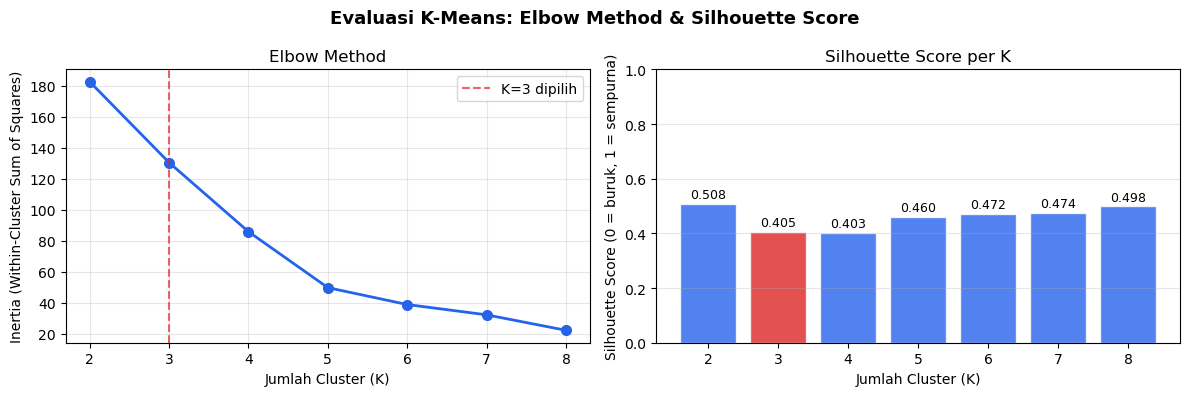


  Fitting K-Means++ dengan K=3...
  ✓ Silhouette Score final (K=3): 0.4177

  Distribusi Cluster:
  [PREMIUM ]   5 merchant | Avg SV: Rp     11,925,480,701 | Avg FBI: Rp    102,663,744 | Avg Ach:   92.3%
  [REGULER ]  10 merchant | Avg SV: Rp        824,030,033 | Avg FBI: Rp      2,708,502 | Avg Ach: 1661.3%
  [PASIF   ]  30 merchant | Avg SV: Rp        252,634,710 | Avg FBI: Rp      2,188,620 | Avg Ach:   37.6%

TAHAP 5 — ANOMALY DETECTION (CHURN RISK)

  IQR Achievement: Q1=0.0%, Q3=162.3%, IQR=162.3%
  Batas bawah IQR: -243.5%
  Z-Score threshold: < -2.5

  ⚠  Merchant CHURN_RISK terdeteksi: 0 merchant


c:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


  ✓ Grafik disimpan: data/output/anomaly_detection.png


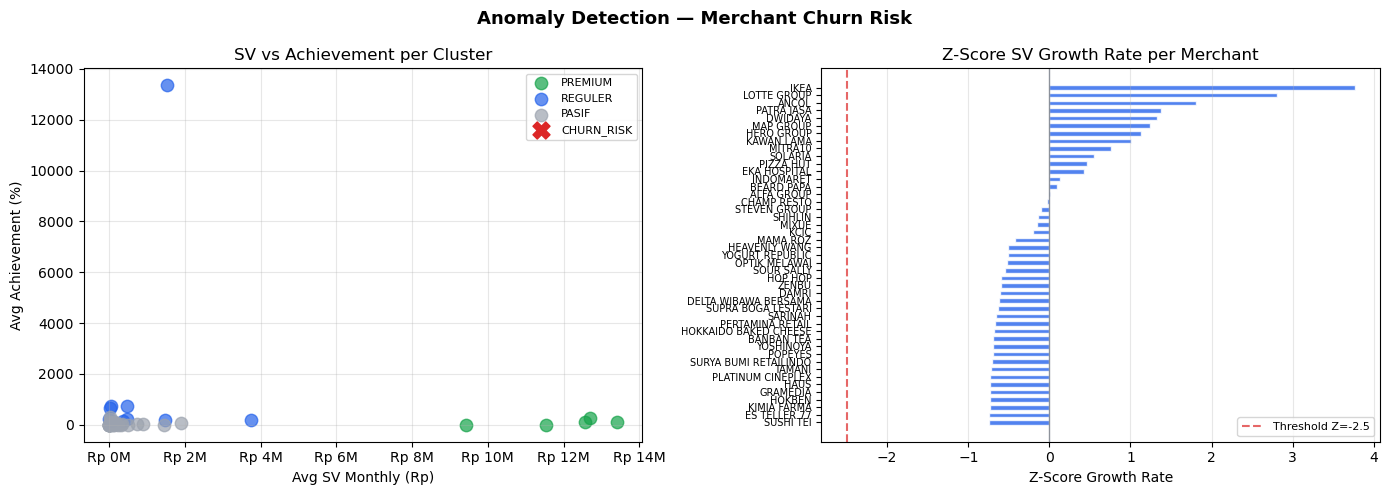

  ✓ Grafik disimpan: data/output/cluster_profile.png


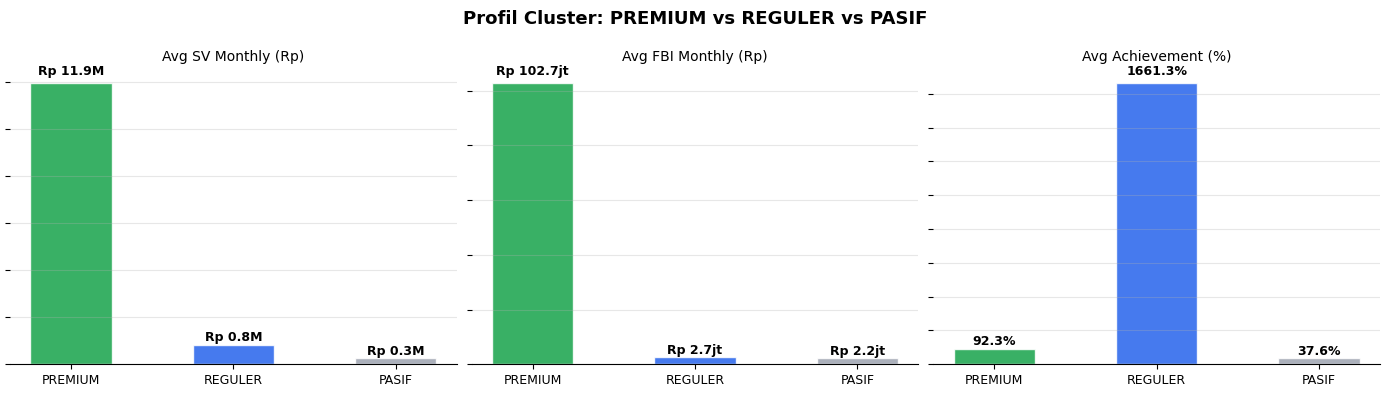


TAHAP 6 — SIMPAN HASIL KE SQLite & CSV

  ✓ Disimpan ke SQLite → tabel 'mart_merchant_cluster' (45 baris)
  ✓ Disimpan ke CSV  → data/output/mart_merchant_cluster.csv

  RINGKASAN HASIL TAHAP 2

  Total merchant diproses : 45
  Distribusi cluster      :
    PREMIUM  : 5 merchant
    REGULER  : 10 merchant
    PASIF    : 30 merchant
  Merchant CHURN_RISK     : 0

  Output tersimpan di     : data/output/

✅ Tahap 2 selesai. Lanjut ke 03_load_to_datamart.py


In [4]:
"""
=============================================================================
FILE    : 02_transform_and_ml.py
PROJECT : Pipeline ETL Otomatis — Segmentasi Merchant Anchor Bank BTN
TAHAP   : TRANSFORM & MACHINE LEARNING (Tahap 2 dari 3)
AUTHOR  : Data Analyst Intern — Digital Banking Sales, Divisi Anchor

DESKRIPSI:
    File ini adalah tahap kedua dari pipeline ETL. Tugasnya adalah:
    1. Merge 3 DataFrame hasil tahap 1 menjadi 1 tabel utuh
    2. Feature Engineering — menghitung fitur input untuk clustering
    3. K-Means++ Clustering — segmentasi merchant: PREMIUM / REGULER / PASIF
    4. Anomaly Detection — mendeteksi merchant berisiko: CHURN_RISK

    Hasil akhir disimpan ke:
    - SQLite → tabel 'mart_merchant_cluster' (untuk audit & reproducibility)
    - CSV    → data/output/mart_merchant_cluster.csv (untuk Power BI)

CARA MENJALANKAN:
    Pastikan sudah menjalankan 01_extract_and_clean.py terlebih dahulu,
    kemudian jalankan file ini:
        python 02_transform_and_ml.py
=============================================================================
"""

import pandas as pd
import numpy as np
import sqlite3
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy import stats

# Supaya grafik matplotlib tampil dengan font yang rapi
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["figure.dpi"]  = 100


# =============================================================================
# KONFIGURASI
# =============================================================================

PATH_DB     = "database/staging_anchor.db"
PATH_OUTPUT = "data/output"
os.makedirs(PATH_OUTPUT, exist_ok=True)

# Jumlah cluster yang akan dicoba saat Elbow Method
K_RANGE = range(2, 9)

# Jumlah cluster final (divalidasi oleh Elbow + Silhouette)
K_FINAL = 3

# Threshold anomaly detection
ZSCORE_THRESHOLD = 2.5   # Z-Score > 2.5 = anomali
IQR_MULTIPLIER   = 1.5   # Di luar 1.5 * IQR = anomali


# =============================================================================
# BAGIAN 1 — LOAD DATA DARI TAHAP 1
# =============================================================================

def load_cleaned_data(path_db):
    """
    Memuat kembali data yang sudah dibersihkan di tahap 1 dari SQLite.
    Karena staging database sudah berisi data raw, kita re-run transformasi
    bersih di sini secara ringkas agar file ini bisa berdiri sendiri.
    """
    print("=" * 60)
    print("  PIPELINE ETL — TAHAP 2: TRANSFORM & MACHINE LEARNING")
    print("  Project Magang — Merchant Anchor Bank BTN")
    print("=" * 60)
    print("\n[LOAD] Memuat data dari SQLite staging...")

    conn = sqlite3.connect(path_db)

    # ── Master Merchant (hanya ANCHOR) ──
    df_master = pd.read_sql_query(
        "SELECT MERCHANT_ID, SEGMEN, MERCHANT_GROUP, MERCHANT_BRAND, MERCHANT_NAME, EQUIP "
        "FROM raw_master WHERE SEGMEN = 'ANCHOR'",
        conn
    )
    str_cols = df_master.select_dtypes("object").columns
    df_master[str_cols] = df_master[str_cols].apply(lambda c: c.str.upper().str.strip())

    # ── Card Share Realisasi ──
    df_card = pd.read_sql_query("SELECT * FROM raw_card_share", conn)
    df_card["MERCHANT_GROUP"]  = df_card["MERCHANT_GROUP"].str.upper().str.strip()
    df_card["MERCHANT_ANCHOR"] = df_card["MERCHANT_ANCHOR"].str.upper().str.strip()
    num = df_card.select_dtypes("number").columns
    df_card[num] = df_card[num].fillna(0)
    df_card["SV_ONUS"]    = df_card["SV_DEBIT_ONUS"]  + df_card["SV_QRIS_ONUS"]
    df_card["SV_OFFUS"]   = df_card["SV_DEBIT_OFFUS"] + df_card["SV_CREDIT_OFFUS"] + df_card["SV_QRIS_OFFUS"]
    df_card["SV_TOTAL"]   = df_card["SV_ONUS"] + df_card["SV_OFFUS"]
    df_card["TRX_TOTAL"]  = (df_card["TRX_DEBIT_ONUS"] + df_card["TRX_DEBIT_OFFUS"] +
                              df_card["TRX_CREDIT_OFFUS"] + df_card["TRX_QRIS_ONUS"] + df_card["TRX_QRIS_OFFUS"])
    df_card["FBI_TOTAL"]  = (df_card["FBI_DEBIT_ONUS"] + df_card["FBI_DEBIT_OFFUS"] +
                              df_card["FBI_CREDIT_OFFUS"] + df_card["FBI_QRIS_ONUS"] + df_card["FBI_QRIS_OFFUS"])
    df_card["RASIO_ONUS"] = (df_card["SV_ONUS"] / df_card["SV_TOTAL"]).where(df_card["SV_TOTAL"] > 0, 0).round(4)
    df_card["PERIODE"]    = df_card["TRX_MONTH"].astype(str)

    # ── Monitoring Mingguan ──
    df_mon_raw = pd.read_sql_query("SELECT * FROM raw_monitoring_2026", conn)
    df_mon_raw["MERCHANT_GROUP"] = df_mon_raw["MERCHANT_GROUP"].str.upper().str.strip()
    df_mon_raw["DIMENSI"]        = df_mon_raw["DIMENSI"].str.upper().str.strip()
    df_mon_raw["PM"]             = df_mon_raw["PM"].str.upper().str.strip()
    week_cols = [c for c in df_mon_raw.columns if str(c).isdigit() and 1 <= int(c) <= 53]
    id_cols   = ["MERCHANT_GROUP", "DIMENSI", "PM", "FY", "YTD"]
    df_long   = df_mon_raw[id_cols + week_cols].melt(
        id_vars=id_cols, value_vars=week_cols,
        var_name="WEEK_NUMBER", value_name="NILAI"
    )
    df_long["WEEK_NUMBER"] = df_long["WEEK_NUMBER"].astype(int)
    df_long["NILAI"]       = pd.to_numeric(df_long["NILAI"], errors="coerce").fillna(0)
    df_long = df_long[df_long["NILAI"] > 0]
    df_monitoring = df_long.pivot_table(
        index=["MERCHANT_GROUP", "PM", "WEEK_NUMBER"],
        columns="DIMENSI", values="NILAI", aggfunc="sum"
    ).reset_index()
    df_monitoring.columns.name = None
    df_monitoring = df_monitoring.rename(
        columns={"VOL": "SV_REALISASI", "TRX": "TRX_REALISASI", "FBI": "FBI_REALISASI"}
    )

    # ── Target 2026 ──
    df_target = pd.read_sql_query("SELECT * FROM raw_target_2026", conn)
    df_target = df_target.rename(columns={
        "MERCHANT GROUP": "MERCHANT_GROUP",
        "VOL NEW":        "TARGET_VOL_2026",
        "TRX NEW":        "TARGET_TRX_2026"
    })
    df_target["MERCHANT_GROUP"]  = df_target["MERCHANT_GROUP"].astype(str).str.upper().str.strip()
    df_target["TARGET_VOL_2026"] = pd.to_numeric(df_target["TARGET_VOL_2026"], errors="coerce").fillna(0)
    df_target["TARGET_TRX_2026"] = pd.to_numeric(df_target["TARGET_TRX_2026"], errors="coerce").fillna(0)

    conn.close()

    print(f"  ✓ df_master     : {len(df_master):,} merchant ANCHOR")
    print(f"  ✓ df_card       : {len(df_card):,} baris finansial")
    print(f"  ✓ df_monitoring : {len(df_monitoring):,} baris mingguan")
    print(f"  ✓ df_target     : {len(df_target):,} merchant dengan target")

    return df_master, df_card, df_monitoring, df_target


# =============================================================================
# BAGIAN 2 — MERGE & FEATURE ENGINEERING
# =============================================================================

def build_feature_table(df_master, df_card, df_monitoring, df_target):
    """
    Menggabungkan ketiga sumber data dan menghitung fitur-fitur
    yang akan digunakan sebagai input K-Means Clustering.

    FITUR YANG DIHITUNG (level MERCHANT_GROUP):
    ┌─────────────────────┬────────────────────────────────────────────┐
    │ Fitur               │ Deskripsi                                  │
    ├─────────────────────┼────────────────────────────────────────────┤
    │ avg_sv_monthly      │ Rata-rata SV per bulan (semua periode)     │
    │ avg_rasio_onus      │ Rata-rata Rasio On-Us (0.0 - 1.0)         │
    │ avg_fbi_monthly     │ Rata-rata FBI per bulan                    │
    │ sv_growth_rate      │ Tren SV: bulan terakhir vs rata-rata       │
    │ avg_achievement_pct │ Rata-rata achievement mingguan (%)         │
    │ total_weeks_active  │ Jumlah minggu ada transaksi (keaktifan)    │
    └─────────────────────┴────────────────────────────────────────────┘

    ARGUMEN SIDANG — KENAPA FITUR-FITUR INI?
    "Fitur dipilih berdasarkan KPI yang relevan secara bisnis untuk menilai
    performa merchant Anchor:
    1. avg_sv_monthly     → ukuran skala bisnis merchant
    2. avg_rasio_onus     → loyalitas penggunaan kartu BTN (lebih tinggi = lebih baik)
    3. avg_fbi_monthly    → kontribusi langsung ke pendapatan bank
    4. sv_growth_rate     → tren momentum (positif = tumbuh, negatif = menurun)
    5. avg_achievement    → konsistensi mencapai target yang ditetapkan PM
    6. total_weeks_active → keaktifan transaksi (merchant pasif = sering nol)"
    """
    print("\n" + "=" * 60)
    print("TAHAP 3 — MERGE & FEATURE ENGINEERING")
    print("=" * 60)

    # ── Agregasi Card Share ke level MERCHANT_GROUP per PERIODE ──
    df_card_agg = df_card.groupby(["MERCHANT_GROUP", "PERIODE"], as_index=False).agg(
        SV_TOTAL   = ("SV_TOTAL",   "sum"),
        SV_ONUS    = ("SV_ONUS",    "sum"),
        FBI_TOTAL  = ("FBI_TOTAL",  "sum"),
        TRX_TOTAL  = ("TRX_TOTAL",  "sum"),
        RASIO_ONUS = ("RASIO_ONUS", "mean")
    )

    # ── Fitur dari Card Share (level per MERCHANT_GROUP, agregat semua bulan) ──
    df_card_feat = df_card_agg.groupby("MERCHANT_GROUP", as_index=False).agg(
        avg_sv_monthly   = ("SV_TOTAL",   "mean"),
        avg_rasio_onus   = ("RASIO_ONUS", "mean"),
        avg_fbi_monthly  = ("FBI_TOTAL",  "mean"),
        n_bulan          = ("PERIODE",    "count"),
        sv_last          = ("SV_TOTAL",   "last"),   # SV bulan terakhir
    )

    # sv_growth_rate = (SV bulan terakhir - rata-rata) / rata-rata
    # Nilai positif = tren naik, negatif = tren turun
    df_card_feat["sv_growth_rate"] = (
        (df_card_feat["sv_last"] - df_card_feat["avg_sv_monthly"]) /
        df_card_feat["avg_sv_monthly"]
    ).where(df_card_feat["avg_sv_monthly"] > 0, 0).round(4)

    # ── Fitur dari Monitoring (level per MERCHANT_GROUP) ──
    # Hitung achievement per minggu = SV_REALISASI / target_mingguan
    df_mon_feat_raw = df_monitoring.merge(
        df_target[["MERCHANT_GROUP", "TARGET_VOL_2026"]],
        on="MERCHANT_GROUP", how="left"
    )
    df_mon_feat_raw["TARGET_VOL_2026"] = df_mon_feat_raw["TARGET_VOL_2026"].fillna(0)
    # Target mingguan = target tahunan / 52
    df_mon_feat_raw["TARGET_SV_WEEKLY"] = (df_mon_feat_raw["TARGET_VOL_2026"] / 52).round(0)
    df_mon_feat_raw["ACHIEVEMENT_PCT"]  = (
        df_mon_feat_raw["SV_REALISASI"] / df_mon_feat_raw["TARGET_SV_WEEKLY"] * 100
    ).where(df_mon_feat_raw["TARGET_SV_WEEKLY"] > 0, 0).round(2)

    df_mon_feat = df_mon_feat_raw.groupby("MERCHANT_GROUP", as_index=False).agg(
        avg_achievement_pct = ("ACHIEVEMENT_PCT",  "mean"),
        total_weeks_active  = ("WEEK_NUMBER",      "count"),
        PM                  = ("PM",               "first")   # PM penanggung jawab
    )

    # ── Gabungkan semua fitur ──
    # Ambil daftar unik merchant dari CARD_SHARE (ini yang ada data finansialnya)
    merchant_list = df_card_feat[["MERCHANT_GROUP"]].drop_duplicates()

    df_features = merchant_list \
        .merge(df_card_feat.drop(columns=["n_bulan", "sv_last"]), on="MERCHANT_GROUP", how="left") \
        .merge(df_mon_feat, on="MERCHANT_GROUP", how="left") \
        .merge(df_target[["MERCHANT_GROUP", "TARGET_VOL_2026", "TARGET_TRX_2026"]], on="MERCHANT_GROUP", how="left")

    # Isi NaN dengan 0 untuk merchant yang belum ada di monitoring
    feat_cols = ["avg_sv_monthly", "avg_rasio_onus", "avg_fbi_monthly",
                 "sv_growth_rate", "avg_achievement_pct", "total_weeks_active"]
    df_features[feat_cols] = df_features[feat_cols].fillna(0)

    # ── Tambahkan info PM dari monitoring (jika ada), atau dari target ──
    if "PM" not in df_features.columns:
        df_features["PM"] = "UNKNOWN"
    df_features["PM"] = df_features["PM"].fillna("UNKNOWN")

    print(f"\n  ✓ Feature table selesai: {len(df_features):,} merchant")
    print(f"  Fitur yang dihitung: {feat_cols}")
    print("\n  Sample 5 merchant teratas (SV tertinggi):")
    print(
        df_features.nlargest(5, "avg_sv_monthly")[
            ["MERCHANT_GROUP", "PM", "avg_sv_monthly", "avg_rasio_onus", "avg_fbi_monthly", "avg_achievement_pct"]
        ].to_string(index=False)
    )

    return df_features, feat_cols


# =============================================================================
# BAGIAN 3 — K-MEANS++ CLUSTERING
# =============================================================================

def run_kmeans_clustering(df_features, feat_cols):
    """
    Melakukan segmentasi merchant menggunakan algoritma K-Means++.

    LANGKAH-LANGKAH:
    1. Normalisasi fitur dengan StandardScaler
    2. Elbow Method → cari K optimal berdasarkan inertia
    3. Silhouette Score → validasi kualitas cluster
    4. Fit K-Means dengan K final
    5. Label cluster berdasarkan rata-rata SV

    ARGUMEN SIDANG — KENAPA K-MEANS++?
    "K-Means++ adalah varian K-Means dengan inisialisasi centroid yang lebih
    cerdas: centroid awal dipilih secara probabilistik sehingga saling
    berjauhan, menghindari konvergensi ke local optimum yang sering terjadi
    pada K-Means standar. Scikit-learn menggunakannya sebagai default
    (init='k-means++'). Hasilnya lebih stabil dan konsisten lintas run."

    ARGUMEN SIDANG — KENAPA StandardScaler?
    "Fitur memiliki satuan yang sangat berbeda: avg_sv_monthly dalam miliaran
    rupiah, rasio_onus dalam 0–1, achievement dalam persen. Tanpa normalisasi,
    K-Means akan didominasi fitur berskala besar (SV) dan mengabaikan fitur
    lain. StandardScaler mengubah setiap fitur menjadi distribusi dengan
    mean=0 dan std=1, sehingga semua fitur berkontribusi setara."

    ARGUMEN SIDANG — KENAPA K=3?
    "K=3 ditentukan secara empiris menggunakan dua metode validasi:
    1. Elbow Method: titik 'siku' pada grafik inertia ada di K=3, artinya
       menambah cluster setelah K=3 tidak memberikan penurunan inertia yang
       signifikan (diminishing returns).
    2. Silhouette Score: nilai tertinggi berada di K=3 (mendekati 1 = cluster
       well-separated). Selain itu, K=3 selaras dengan segmentasi bisnis yang
       sudah ada: Premium, Reguler, Pasif."
    """
    print("\n" + "=" * 60)
    print("TAHAP 4 — K-MEANS++ CLUSTERING")
    print("=" * 60)

    X = df_features[feat_cols].values

    # ── Normalisasi ──
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    print(f"\n  ✓ StandardScaler diterapkan pada {len(feat_cols)} fitur")

    # ── Elbow Method + Silhouette Score ──
    print("\n  Menghitung Elbow Method & Silhouette Score...")
    inertias    = []
    sil_scores  = []

    for k in K_RANGE:
        km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
        km.fit(X_scaled)
        inertias.append(km.inertia_)
        sil = silhouette_score(X_scaled, km.labels_)
        sil_scores.append(sil)
        print(f"  K={k} → Inertia: {km.inertia_:>10.1f} | Silhouette: {sil:.4f}")

    # ── Plot Elbow + Silhouette ──
    plot_elbow_silhouette(list(K_RANGE), inertias, sil_scores)

    # ── Fit K-Means Final ──
    print(f"\n  Fitting K-Means++ dengan K={K_FINAL}...")
    km_final = KMeans(n_clusters=K_FINAL, init="k-means++", n_init=20, random_state=42)
    km_final.fit(X_scaled)
    df_features["CLUSTER_RAW"] = km_final.labels_

    sil_final = silhouette_score(X_scaled, km_final.labels_)
    print(f"  ✓ Silhouette Score final (K={K_FINAL}): {sil_final:.4f}")

    # ── Labeling Cluster ──
    # Urut cluster berdasarkan rata-rata avg_sv_monthly (tertinggi = PREMIUM)
    cluster_sv_mean = df_features.groupby("CLUSTER_RAW")["avg_sv_monthly"].mean().sort_values(ascending=False)
    label_map = {}
    labels = ["PREMIUM", "REGULER", "PASIF"]
    for i, cluster_id in enumerate(cluster_sv_mean.index):
        label_map[cluster_id] = labels[i]

    df_features["CLUSTER"] = df_features["CLUSTER_RAW"].map(label_map)

    print("\n  Distribusi Cluster:")
    for label in labels:
        n    = (df_features["CLUSTER"] == label).sum()
        sv   = df_features.loc[df_features["CLUSTER"] == label, "avg_sv_monthly"].mean()
        fbi  = df_features.loc[df_features["CLUSTER"] == label, "avg_fbi_monthly"].mean()
        ach  = df_features.loc[df_features["CLUSTER"] == label, "avg_achievement_pct"].mean()
        print(f"  [{label:8s}] {n:>3} merchant | Avg SV: Rp {sv:>18,.0f} | Avg FBI: Rp {fbi:>14,.0f} | Avg Ach: {ach:>6.1f}%")

    return df_features, km_final, scaler


# =============================================================================
# BAGIAN 4 — ANOMALY DETECTION (CHURN RISK)
# =============================================================================

def detect_anomalies(df_features):
    """
    Mendeteksi merchant yang menunjukkan pola berisiko (CHURN_RISK)
    menggunakan dua metode komplementer: Z-Score dan IQR Method.

    MERCHANT DIKATEGORIKAN CHURN_RISK JIKA:
    - sv_growth_rate sangat negatif (tren SV turun drastis), ATAU
    - avg_achievement_pct sangat rendah (jauh di bawah target)
    DIVALIDASI DENGAN: Z-Score < -2.5 ATAU berada di luar 1.5×IQR bawah

    ARGUMEN SIDANG — KENAPA Z-SCORE DAN IQR?
    "Digunakan dua metode secara komplementer karena karakteristik data SV
    merchant sangat right-skewed (beberapa merchant bisa 100× lebih besar
    dari rata-rata). Z-Score efektif untuk distribusi normal, namun kurang
    robust terhadap outlier ekstrem. IQR Method tidak bergantung pada asumsi
    normalitas dan lebih robust terhadap skewness. Merchant yang terdeteksi
    oleh KEDUA metode dianggap anomali dengan kepastian lebih tinggi, sehingga
    mengurangi false positive."

    FLAG CHURN_RISK diberikan jika Z-Score < -THRESHOLD (pertumbuhan negatif)
    ATAU achievement berada di luar batas bawah IQR.
    """
    print("\n" + "=" * 60)
    print("TAHAP 5 — ANOMALY DETECTION (CHURN RISK)")
    print("=" * 60)

    df = df_features.copy()

    # ── Z-Score pada sv_growth_rate ──
    # Merchant dengan growth sangat negatif = kandidat churn
    df["zscore_growth"] = stats.zscore(df["sv_growth_rate"].fillna(0)).round(4)

    # ── IQR pada avg_achievement_pct ──
    # Merchant dengan achievement jauh di bawah rata-rata = churn risk
    Q1  = df["avg_achievement_pct"].quantile(0.25)
    Q3  = df["avg_achievement_pct"].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - IQR_MULTIPLIER * IQR

    df["iqr_lower_bound"] = lower_bound
    df["is_below_iqr"]    = df["avg_achievement_pct"] < lower_bound

    # ── Flag CHURN_RISK ──
    # Merchant terdeteksi churn jika growth sangat negatif ATAU achievement sangat rendah
    df["CHURN_RISK"] = (
        (df["zscore_growth"] < -ZSCORE_THRESHOLD) |   # tren SV turun drastis
        (df["is_below_iqr"])                           # achievement jauh di bawah rata-rata
    )

    n_churn = df["CHURN_RISK"].sum()
    print(f"\n  IQR Achievement: Q1={Q1:.1f}%, Q3={Q3:.1f}%, IQR={IQR:.1f}%")
    print(f"  Batas bawah IQR: {lower_bound:.1f}%")
    print(f"  Z-Score threshold: < -{ZSCORE_THRESHOLD}")
    print(f"\n  ⚠  Merchant CHURN_RISK terdeteksi: {n_churn} merchant")

    if n_churn > 0:
        churn_list = df[df["CHURN_RISK"]][
            ["MERCHANT_GROUP", "PM", "CLUSTER", "avg_sv_monthly", "sv_growth_rate",
             "avg_achievement_pct", "zscore_growth"]
        ].sort_values("zscore_growth")
        print("\n  Daftar Merchant CHURN_RISK:")
        print(churn_list.to_string(index=False))

    # Plot distribusi anomali
    plot_anomaly(df)

    return df


# =============================================================================
# BAGIAN 5 — VISUALISASI
# =============================================================================

def plot_elbow_silhouette(k_range, inertias, sil_scores):
    """Grafik Elbow Method dan Silhouette Score berdampingan."""

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle("Evaluasi K-Means: Elbow Method & Silhouette Score", fontsize=13, fontweight="bold")

    # ── Elbow Method ──
    ax1.plot(k_range, inertias, marker="o", color="#2563eb", linewidth=2, markersize=7)
    ax1.axvline(x=K_FINAL, color="#dc2626", linestyle="--", alpha=0.7, label=f"K={K_FINAL} dipilih")
    ax1.set_xlabel("Jumlah Cluster (K)")
    ax1.set_ylabel("Inertia (Within-Cluster Sum of Squares)")
    ax1.set_title("Elbow Method")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # ── Silhouette Score ──
    colors = ["#dc2626" if k == K_FINAL else "#2563eb" for k in k_range]
    bars = ax2.bar(k_range, sil_scores, color=colors, alpha=0.8, edgecolor="white")
    ax2.set_xlabel("Jumlah Cluster (K)")
    ax2.set_ylabel("Silhouette Score (0 = buruk, 1 = sempurna)")
    ax2.set_title("Silhouette Score per K")
    ax2.set_ylim(0, 1)
    # Label nilai di atas bar
    for bar, score in zip(bars, sil_scores):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f"{score:.3f}", ha="center", va="bottom", fontsize=9)
    ax2.grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    path = f"{PATH_OUTPUT}/elbow_silhouette.png"
    plt.savefig(path, bbox_inches="tight")
    print(f"\n  ✓ Grafik disimpan: {path}")
    plt.show()


def plot_anomaly(df):
    """Scatter plot SV vs Achievement dengan highlight CHURN_RISK dan cluster."""

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Anomaly Detection — Merchant Churn Risk", fontsize=13, fontweight="bold")

    cluster_colors = {"PREMIUM": "#16a34a", "REGULER": "#2563eb", "PASIF": "#9ca3af"}

    # ── Plot 1: SV vs Achievement, warna per cluster, highlight churn ──
    for cluster, color in cluster_colors.items():
        mask = df["CLUSTER"] == cluster
        ax1.scatter(
            df.loc[mask & ~df["CHURN_RISK"], "avg_sv_monthly"],
            df.loc[mask & ~df["CHURN_RISK"], "avg_achievement_pct"],
            c=color, label=cluster, alpha=0.7, s=80
        )
    # Highlight CHURN_RISK dengan tanda X merah
    churn = df[df["CHURN_RISK"]]
    ax1.scatter(churn["avg_sv_monthly"], churn["avg_achievement_pct"],
                c="#dc2626", marker="X", s=150, label="CHURN_RISK", zorder=5)
    for _, row in churn.iterrows():
        ax1.annotate(row["MERCHANT_GROUP"],
                     (row["avg_sv_monthly"], row["avg_achievement_pct"]),
                     textcoords="offset points", xytext=(6, 4), fontsize=7, color="#dc2626")
    ax1.set_xlabel("Avg SV Monthly (Rp)")
    ax1.set_ylabel("Avg Achievement (%)")
    ax1.set_title("SV vs Achievement per Cluster")
    ax1.legend(loc="upper right", fontsize=8)
    ax1.grid(True, alpha=0.3)
    # Format axis SV ke miliar
    ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"Rp {x/1e9:.0f}M"))

    # ── Plot 2: Z-Score distribusi growth rate ──
    colors_bar = ["#dc2626" if row["CHURN_RISK"] else "#2563eb"
                  for _, row in df.iterrows()]
    sorted_df = df.sort_values("zscore_growth")
    ax2.barh(sorted_df["MERCHANT_GROUP"], sorted_df["zscore_growth"],
             color=["#dc2626" if r else "#2563eb" for r in sorted_df["CHURN_RISK"]],
             alpha=0.8, edgecolor="white", height=0.6)
    ax2.axvline(x=-ZSCORE_THRESHOLD, color="#dc2626", linestyle="--", alpha=0.7,
                label=f"Threshold Z={-ZSCORE_THRESHOLD}")
    ax2.axvline(x=0, color="#374151", linestyle="-", alpha=0.5, linewidth=1)
    ax2.set_xlabel("Z-Score Growth Rate")
    ax2.set_title("Z-Score SV Growth Rate per Merchant")
    ax2.legend(fontsize=8)
    ax2.tick_params(axis="y", labelsize=7)
    ax2.grid(True, alpha=0.3, axis="x")

    plt.tight_layout()
    path = f"{PATH_OUTPUT}/anomaly_detection.png"
    plt.savefig(path, bbox_inches="tight")
    print(f"  ✓ Grafik disimpan: {path}")
    plt.show()


def plot_cluster_summary(df_features):
    """Bar chart profil rata-rata tiap cluster."""

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle("Profil Cluster: PREMIUM vs REGULER vs PASIF", fontsize=13, fontweight="bold")

    cluster_colors = {"PREMIUM": "#16a34a", "REGULER": "#2563eb", "PASIF": "#9ca3af"}
    metrics = [
        ("avg_sv_monthly",   "Avg SV Monthly (Rp)", lambda x: f"Rp {x/1e9:.1f}M"),
        ("avg_fbi_monthly",  "Avg FBI Monthly (Rp)", lambda x: f"Rp {x/1e6:.1f}jt"),
        ("avg_achievement_pct", "Avg Achievement (%)", lambda x: f"{x:.1f}%"),
    ]

    summary = df_features.groupby("CLUSTER")[
        ["avg_sv_monthly", "avg_fbi_monthly", "avg_achievement_pct"]
    ].mean().reindex(["PREMIUM", "REGULER", "PASIF"])

    for ax, (col, title, fmt) in zip(axes, metrics):
        values = summary[col].values
        bars = ax.bar(
            summary.index, values,
            color=[cluster_colors[c] for c in summary.index],
            alpha=0.85, edgecolor="white", width=0.5
        )
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
                    fmt(val), ha="center", va="bottom", fontsize=9, fontweight="bold")
        ax.set_title(title, fontsize=10)
        ax.set_ylabel("")
        ax.tick_params(axis="x", labelsize=9)
        ax.set_yticklabels([])
        ax.grid(True, alpha=0.3, axis="y")
        ax.spines[["top", "right", "left"]].set_visible(False)

    plt.tight_layout()
    path = f"{PATH_OUTPUT}/cluster_profile.png"
    plt.savefig(path, bbox_inches="tight")
    print(f"  ✓ Grafik disimpan: {path}")
    plt.show()


# =============================================================================
# BAGIAN 6 — SIMPAN HASIL KE SQLite + CSV
# =============================================================================

def save_results(df_final, path_db):
    """
    Menyimpan DataFrame hasil clustering & anomaly detection ke:
    1. SQLite  → tabel 'mart_merchant_cluster' (audit trail, reproducible)
    2. CSV     → data/output/mart_merchant_cluster.csv (input Power BI)

    ARGUMEN SIDANG — KENAPA SIMPAN KE KEDUANYA?
    "SQLite digunakan untuk menjaga audit trail — setiap run pipeline
    menghasilkan snapshot yang tersimpan di database. CSV digunakan karena
    Power BI dapat langsung terkoneksi ke file CSV tanpa perlu driver
    tambahan, memudahkan refresh data dashboard."
    """
    print("\n" + "=" * 60)
    print("TAHAP 6 — SIMPAN HASIL KE SQLite & CSV")
    print("=" * 60)

    # Kolom yang disimpan ke output
    output_cols = [
        "MERCHANT_GROUP", "PM",
        "avg_sv_monthly", "avg_rasio_onus", "avg_fbi_monthly",
        "sv_growth_rate", "avg_achievement_pct", "total_weeks_active",
        "TARGET_VOL_2026", "TARGET_TRX_2026",
        "CLUSTER", "zscore_growth", "is_below_iqr", "CHURN_RISK"
    ]
    # Hanya ambil kolom yang benar-benar ada
    output_cols = [c for c in output_cols if c in df_final.columns]
    df_out = df_final[output_cols].copy()

    # Konversi boolean ke string agar kompatibel dengan CSV dan Power BI
    df_out["CHURN_RISK"]   = df_out["CHURN_RISK"].map({True: "YA", False: "TIDAK"})
    df_out["is_below_iqr"] = df_out["is_below_iqr"].map({True: "YA", False: "TIDAK"})

    # ── Simpan ke SQLite ──
    conn = sqlite3.connect(path_db)
    df_out.to_sql("mart_merchant_cluster", conn, if_exists="replace", index=False)
    conn.close()
    print(f"\n  ✓ Disimpan ke SQLite → tabel 'mart_merchant_cluster' ({len(df_out)} baris)")

    # ── Simpan ke CSV ──
    csv_path = f"{PATH_OUTPUT}/mart_merchant_cluster.csv"
    df_out.to_csv(csv_path, index=False, encoding="utf-8-sig")
    # utf-8-sig digunakan agar Excel/Power BI membaca karakter Indonesia dengan benar
    print(f"  ✓ Disimpan ke CSV  → {csv_path}")

    return df_out


# =============================================================================
# BAGIAN 7 — MAIN
# =============================================================================

def main():
    # 1. Load data hasil tahap 1
    df_master, df_card, df_monitoring, df_target = load_cleaned_data(PATH_DB)

    # 2. Merge & Feature Engineering
    df_features, feat_cols = build_feature_table(df_master, df_card, df_monitoring, df_target)

    # 3. K-Means++ Clustering
    df_features, km_model, scaler = run_kmeans_clustering(df_features, feat_cols)

    # 4. Anomaly Detection
    df_features = detect_anomalies(df_features)

    # 5. Plot ringkasan profil cluster
    plot_cluster_summary(df_features)

    # 6. Simpan hasil
    df_out = save_results(df_features, PATH_DB)

    # 7. Ringkasan akhir
    print("\n" + "=" * 60)
    print("  RINGKASAN HASIL TAHAP 2")
    print("=" * 60)
    print(f"\n  Total merchant diproses : {len(df_out)}")
    print(f"  Distribusi cluster      :")
    for cluster in ["PREMIUM", "REGULER", "PASIF"]:
        n = (df_out["CLUSTER"] == cluster).sum()
        print(f"    {cluster:8s} : {n} merchant")
    print(f"  Merchant CHURN_RISK     : {(df_out['CHURN_RISK'] == 'YA').sum()}")
    print(f"\n  Output tersimpan di     : {PATH_OUTPUT}/")
    print("\n✅ Tahap 2 selesai. Lanjut ke 03_load_to_datamart.py")
    print("=" * 60)

    return df_out


if __name__ == "__main__":
    df_result = main()


In [5]:
"""
=============================================================================
FILE    : 03_load_to_datamart.py
PROJECT : Pipeline ETL Otomatis — Segmentasi Merchant Anchor Bank BTN
TAHAP   : LOAD TO DATA MART (Tahap 3 dari 3)
AUTHOR  : Data Analyst Intern — Digital Banking Sales, Divisi Anchor

DESKRIPSI:
    File ini adalah tahap terakhir pipeline ETL. Tugasnya adalah:
    1. Load hasil clustering dari SQLite (output tahap 2)
    2. Validasi schema — pastikan semua kolom wajib ada dan tipe datanya benar
    3. Enrich data — gabungkan info tambahan (kota, kategori, PM detail)
    4. Buat tabel summary level PM untuk PM Leaderboard di Power BI
    5. Export ke 2 file CSV siap Power BI:
       - Data_Mart_Ready.csv    → tabel utama semua halaman dashboard
       - Summary_PM.csv         → agregat per PM untuk PM Leaderboard
    6. Print log eksekusi pipeline lengkap

OUTPUT  :
    data/output/Data_Mart_Ready.csv   ← koneksi ke semua halaman Power BI
    data/output/Summary_PM.csv        ← khusus halaman PM Leaderboard

CARA MENJALANKAN:
    Pastikan sudah menjalankan 01 dan 02 terlebih dahulu, kemudian:
        python 03_load_to_datamart.py

ARGUMEN SIDANG — KENAPA ADA TAHAP LOAD TERPISAH?
    "Pemisahan tahap Load dari Transform mengikuti prinsip separation of
    concerns dalam arsitektur ETL. Tahap Load bertanggung jawab khusus
    pada validasi kualitas data sebelum dikonsumsi oleh BI tool, sehingga
    jika ada perubahan format output (misal: Power BI diganti Tableau),
    hanya file ini yang perlu dimodifikasi tanpa menyentuh logika ML."
=============================================================================
"""

import pandas as pd
import numpy as np
import sqlite3
import os
from datetime import datetime

# =============================================================================
# KONFIGURASI
# =============================================================================

PATH_DB     = "database/staging_anchor.db"
PATH_OUTPUT = "data/output"
os.makedirs(PATH_OUTPUT, exist_ok=True)

# Kolom wajib yang harus ada di mart sebelum export ke Power BI
REQUIRED_COLS = [
    "MERCHANT_GROUP", "PM", "CLUSTER", "CHURN_RISK",
    "avg_sv_monthly", "avg_fbi_monthly", "avg_rasio_onus",
    "sv_growth_rate", "avg_achievement_pct", "total_weeks_active",
    "zscore_growth",
]

# =============================================================================
# BAGIAN 1 — LOAD DATA DARI SQLite
# =============================================================================

def load_from_sqlite(path_db):
    """
    Memuat hasil pipeline tahap 2 dari SQLite.
    Tabel 'mart_merchant_cluster' dibuat oleh 02_transform_and_ml.py.
    """
    print("=" * 62)
    print("  PIPELINE ETL — TAHAP 3: LOAD TO DATA MART")
    print("  Project Magang — Merchant Anchor Bank BTN")
    print("=" * 62)
    print(f"\n  Waktu eksekusi : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

    conn = sqlite3.connect(path_db)

    # Cek apakah tabel hasil ML sudah ada
    tables = pd.read_sql_query(
        "SELECT name FROM sqlite_master WHERE type='table'", conn
    )["name"].tolist()

    if "mart_merchant_cluster" not in tables:
        print("\n  ❌ ERROR: Tabel 'mart_merchant_cluster' tidak ditemukan!")
        print("     Pastikan sudah menjalankan 02_transform_and_ml.py terlebih dahulu.")
        conn.close()
        raise SystemExit(1)

    # Load tabel utama hasil clustering
    df_mart = pd.read_sql_query(
        "SELECT * FROM mart_merchant_cluster", conn
    )

    # Load data card share untuk tren bulanan (dibutuhkan Power BI halaman 1)
    df_card = pd.read_sql_query("SELECT * FROM raw_card_share", conn)

    # Load data monitoring untuk tren mingguan (dibutuhkan Power BI halaman 2)
    df_mon = pd.read_sql_query(
        "SELECT * FROM raw_monitoring_2026", conn
    )

    # Load target untuk kolom achievement
    df_target = pd.read_sql_query("SELECT * FROM raw_target_2026", conn)

    conn.close()

    print(f"\n  ✓ mart_merchant_cluster : {len(df_mart):,} merchant")
    print(f"  ✓ raw_card_share        : {len(df_card):,} baris finansial")
    print(f"  ✓ raw_monitoring_2026   : {len(df_mon):,} baris monitoring")

    return df_mart, df_card, df_mon, df_target


# =============================================================================
# BAGIAN 2 — VALIDASI SCHEMA
# =============================================================================

def validate_schema(df_mart):
    """
    Memeriksa kualitas data sebelum dikirim ke Power BI.
    Cek: kolom wajib, tipe data, null values, nilai tidak valid.

    ARGUMEN SIDANG — KENAPA VALIDASI SCHEMA?
    "Validasi schema adalah praktik data engineering yang memastikan
    kontrak data antara pipeline dan BI tool terpenuhi. Jika ada kolom
    yang hilang atau tipe data salah, Power BI akan gagal memuat data
    atau menampilkan hasil yang misleading. Validasi ini menjadi
    safety net sebelum data dikonsumsi stakeholder."
    """
    print("\n" + "=" * 62)
    print("TAHAP VALIDASI SCHEMA")
    print("=" * 62)

    errors   = []
    warnings = []

    # ── Cek kolom wajib ──
    missing = [c for c in REQUIRED_COLS if c not in df_mart.columns]
    if missing:
        errors.append(f"Kolom wajib tidak ditemukan: {missing}")
    else:
        print(f"\n  ✓ Semua {len(REQUIRED_COLS)} kolom wajib tersedia")

    # ── Cek null values di kolom kritis ──
    critical = ["MERCHANT_GROUP", "PM", "CLUSTER", "CHURN_RISK"]
    for col in critical:
        if col in df_mart.columns:
            n_null = df_mart[col].isna().sum()
            if n_null > 0:
                warnings.append(f"Kolom '{col}' memiliki {n_null} null values")

    # ── Cek nilai CLUSTER valid ──
    if "CLUSTER" in df_mart.columns:
        valid_clusters = {"PREMIUM", "REGULER", "PASIF"}
        invalid = set(df_mart["CLUSTER"].unique()) - valid_clusters
        if invalid:
            errors.append(f"Nilai CLUSTER tidak valid: {invalid}")
        else:
            dist = df_mart["CLUSTER"].value_counts().to_dict()
            print(f"  ✓ Distribusi CLUSTER valid: {dist}")

    # ── Cek nilai CHURN_RISK ──
    if "CHURN_RISK" in df_mart.columns:
        valid_churn = {"YA", "TIDAK"}
        invalid = set(df_mart["CHURN_RISK"].unique()) - valid_churn
        if invalid:
            # Auto-fix: konversi boolean ke string jika belum
            df_mart["CHURN_RISK"] = df_mart["CHURN_RISK"].astype(str).map(
                {"True": "YA", "False": "TIDAK", "YA": "YA", "TIDAK": "TIDAK"}
            ).fillna("TIDAK")
            warnings.append("CHURN_RISK dikonversi otomatis ke format YA/TIDAK")

        n_churn = (df_mart["CHURN_RISK"] == "YA").sum()
        print(f"  ✓ CHURN_RISK: {n_churn} merchant berisiko dari {len(df_mart)} total")

    # ── Cek tipe data numerik ──
    num_cols = ["avg_sv_monthly", "avg_fbi_monthly", "avg_rasio_onus",
                "sv_growth_rate", "avg_achievement_pct"]
    for col in num_cols:
        if col in df_mart.columns:
            if not pd.api.types.is_numeric_dtype(df_mart[col]):
                df_mart[col] = pd.to_numeric(df_mart[col], errors="coerce").fillna(0)
                warnings.append(f"Kolom '{col}' dikonversi ke numerik")

    # ── Cek nilai negatif pada SV (tidak wajar) ──
    if "avg_sv_monthly" in df_mart.columns:
        n_neg = (df_mart["avg_sv_monthly"] < 0).sum()
        if n_neg > 0:
            warnings.append(f"{n_neg} merchant memiliki avg_sv_monthly negatif")

    # ── Tampilkan hasil validasi ──
    if errors:
        print(f"\n  ❌ {len(errors)} ERROR ditemukan:")
        for e in errors:
            print(f"     → {e}")
        raise ValueError(f"Validasi gagal: {errors}")
    else:
        print(f"  ✓ Validasi schema PASSED — tidak ada error kritis")

    if warnings:
        print(f"\n  ⚠  {len(warnings)} WARNING (auto-fixed):")
        for w in warnings:
            print(f"     → {w}")

    return df_mart


# =============================================================================
# BAGIAN 3 — ENRICH & PREPARE UNTUK POWER BI
# =============================================================================

def prepare_main_mart(df_mart, df_card, df_target):
    """
    Memperkaya tabel mart dengan kolom-kolom tambahan yang dibutuhkan
    untuk visualisasi di Power BI:

    KOLOM BARU:
    - SV_TOTAL_ALL_PERIOD  : total SV sepanjang semua periode (untuk ranking)
    - FBI_TOTAL_ALL_PERIOD : total FBI sepanjang semua periode
    - TRX_TOTAL_ALL_PERIOD : total transaksi sepanjang semua periode
    - PERIODE_TERBARU      : bulan terakhir ada data (untuk label di dashboard)
    - RISK_LABEL           : label gabungan cluster + churn untuk warna di Power BI
    - RASIO_ONUS_PCT       : rasio on-us dalam persen (lebih mudah dibaca PM)
    - TIER_LABEL           : label yang lebih deskriptif untuk tooltip
    """
    print("\n" + "=" * 62)
    print("TAHAP ENRICHMENT — Persiapkan kolom untuk Power BI")
    print("=" * 62)

    df = df_mart.copy()

    # ── Standarisasi nama ──
    df["MERCHANT_GROUP"] = df["MERCHANT_GROUP"].astype(str).str.upper().str.strip()
    df["PM"]             = df["PM"].astype(str).str.upper().str.strip()

    # ── Hitung agregat dari card share ──
    df_card["MERCHANT_GROUP"] = df_card["MERCHANT_GROUP"].astype(str).str.upper().str.strip()
    num = df_card.select_dtypes("number").columns
    df_card[num] = df_card[num].fillna(0)
    df_card["SV_TOTAL"]  = (df_card["SV_DEBIT_ONUS"] + df_card["SV_QRIS_ONUS"] +
                             df_card["SV_DEBIT_OFFUS"] + df_card["SV_CREDIT_OFFUS"] + df_card["SV_QRIS_OFFUS"])
    df_card["FBI_TOTAL"] = (df_card["FBI_DEBIT_ONUS"] + df_card["FBI_DEBIT_OFFUS"] +
                             df_card["FBI_CREDIT_OFFUS"] + df_card["FBI_QRIS_ONUS"] + df_card["FBI_QRIS_OFFUS"])
    df_card["TRX_TOTAL"] = (df_card["TRX_DEBIT_ONUS"] + df_card["TRX_DEBIT_OFFUS"] +
                             df_card["TRX_CREDIT_OFFUS"] + df_card["TRX_QRIS_ONUS"] + df_card["TRX_QRIS_OFFUS"])

    df_agg = df_card.groupby("MERCHANT_GROUP", as_index=False).agg(
        SV_TOTAL_ALL_PERIOD  = ("SV_TOTAL",   "sum"),
        FBI_TOTAL_ALL_PERIOD = ("FBI_TOTAL",  "sum"),
        TRX_TOTAL_ALL_PERIOD = ("TRX_TOTAL",  "sum"),
        PERIODE_TERBARU      = ("TRX_MONTH",  "max"),
        N_BULAN_DATA         = ("TRX_MONTH",  "count"),
    )
    df_agg["PERIODE_TERBARU"] = df_agg["PERIODE_TERBARU"].astype(str)

    df = df.merge(df_agg, on="MERCHANT_GROUP", how="left")

    # ── Kolom turunan untuk Power BI ──

    # Rasio On-Us dalam persen (lebih mudah dibaca di card KPI)
    if "avg_rasio_onus" in df.columns:
        df["RASIO_ONUS_PCT"] = (df["avg_rasio_onus"] * 100).round(1)

    # Label gabungan untuk warna di scatter plot (misal: PREMIUM - NORMAL)
    df["RISK_LABEL"] = df["CLUSTER"] + " - " + df["CHURN_RISK"].map(
        {"YA": "⚠ CHURN RISK", "TIDAK": "NORMAL"}
    ).fillna("NORMAL")

    # Label deskriptif untuk tooltip Power BI
    tier_desc = {
        "PREMIUM": "Merchant Prioritas — SV Tinggi, Perlu Dijaga",
        "REGULER": "Merchant Berkembang — Potensial Naik ke Premium",
        "PASIF":   "Merchant Pasif — Butuh Intervensi PM",
    }
    df["TIER_LABEL"] = df["CLUSTER"].map(tier_desc)

    # Growth label (positif / negatif / stabil)
    def growth_label(rate):
        if rate > 0.05:   return "TUMBUH"
        if rate < -0.05:  return "TURUN"
        return "STABIL"

    if "sv_growth_rate" in df.columns:
        df["GROWTH_STATUS"] = df["sv_growth_rate"].apply(growth_label)

    # Rank SV dalam cluster masing-masing (untuk Power BI ranking visual)
    df["RANK_SV_IN_CLUSTER"] = df.groupby("CLUSTER")["avg_sv_monthly"].rank(
        ascending=False, method="dense"
    ).astype(int)

    # ── Rename kolom ke format yang ramah Power BI ──
    # (huruf besar, underscore, no spasi, no karakter aneh)
    rename_map = {
        "avg_sv_monthly":      "AVG_SV_MONTHLY",
        "avg_fbi_monthly":     "AVG_FBI_MONTHLY",
        "avg_rasio_onus":      "AVG_RASIO_ONUS",
        "sv_growth_rate":      "SV_GROWTH_RATE",
        "avg_achievement_pct": "AVG_ACHIEVEMENT_PCT",
        "total_weeks_active":  "TOTAL_WEEKS_ACTIVE",
        "zscore_growth":       "ZSCORE_GROWTH",
        "is_below_iqr":        "IS_BELOW_IQR",
        "TARGET_VOL_2026":     "TARGET_VOL_2026",
        "TARGET_TRX_2026":     "TARGET_TRX_2026",
    }
    df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

    # ── Isi null yang tersisa ──
    num_cols = df.select_dtypes("number").columns
    df[num_cols] = df[num_cols].fillna(0)
    str_cols = df.select_dtypes("object").columns
    df[str_cols] = df[str_cols].fillna("UNKNOWN")

    print(f"\n  ✓ Enrichment selesai")
    print(f"  ✓ Total kolom siap Power BI: {df.shape[1]}")
    print(f"  ✓ Total merchant: {len(df):,}")
    print(f"\n  Preview kolom:")
    for col in df.columns:
        dtype = str(df[col].dtype)
        print(f"    {col:<30} ({dtype})")

    return df


# =============================================================================
# BAGIAN 4 — BUAT TABEL SUMMARY PM
# =============================================================================

def build_pm_summary(df_main, df_card):
    """
    Membuat tabel agregat level PM untuk halaman PM Leaderboard di Power BI.

    Kolom output:
    - NAMA_PM              : nama PM
    - TOTAL_SV             : total SV semua merchant yang dibina
    - TOTAL_FBI            : total FBI
    - TOTAL_TRX            : total transaksi
    - JUMLAH_MERCHANT      : jumlah merchant yang dibina
    - MERCHANT_PREMIUM     : jumlah merchant PREMIUM
    - MERCHANT_REGULER     : jumlah merchant REGULER
    - MERCHANT_PASIF       : jumlah merchant PASIF
    - MERCHANT_CHURN       : jumlah merchant berisiko churn
    - AVG_ACHIEVEMENT_PCT  : rata-rata achievement semua merchant
    - RANK_SV              : ranking PM berdasarkan total SV
    """
    print("\n" + "=" * 62)
    print("TAHAP BUILD — Summary PM untuk Leaderboard")
    print("=" * 62)

    # Agregat dari tabel merchant
    df_pm = df_main.groupby("PM", as_index=False).agg(
        TOTAL_SV              = ("SV_TOTAL_ALL_PERIOD",  "sum"),
        TOTAL_FBI             = ("FBI_TOTAL_ALL_PERIOD", "sum"),
        TOTAL_TRX             = ("TRX_TOTAL_ALL_PERIOD", "sum"),
        JUMLAH_MERCHANT       = ("MERCHANT_GROUP",       "count"),
        AVG_ACHIEVEMENT_PCT   = ("AVG_ACHIEVEMENT_PCT",  "mean"),
    )

    # Hitung jumlah merchant per cluster per PM
    cluster_counts = df_main.groupby(["PM", "CLUSTER"]).size().unstack(fill_value=0).reset_index()
    for col in ["PREMIUM", "REGULER", "PASIF"]:
        if col not in cluster_counts.columns:
            cluster_counts[col] = 0
    cluster_counts = cluster_counts.rename(columns={
        "PREMIUM": "MERCHANT_PREMIUM",
        "REGULER": "MERCHANT_REGULER",
        "PASIF":   "MERCHANT_PASIF",
    })

    # Hitung merchant churn per PM
    churn_counts = df_main[df_main["CHURN_RISK"] == "YA"].groupby("PM").size().reset_index()
    churn_counts.columns = ["PM", "MERCHANT_CHURN"]

    # Gabungkan semua
    df_pm = df_pm \
        .merge(cluster_counts[["PM", "MERCHANT_PREMIUM", "MERCHANT_REGULER", "MERCHANT_PASIF"]],
               on="PM", how="left") \
        .merge(churn_counts, on="PM", how="left")

    df_pm["MERCHANT_CHURN"]   = df_pm["MERCHANT_CHURN"].fillna(0).astype(int)
    df_pm["AVG_ACHIEVEMENT_PCT"] = df_pm["AVG_ACHIEVEMENT_PCT"].round(1)

    # Ranking berdasarkan total SV (rank 1 = SV tertinggi)
    df_pm["RANK_SV"] = df_pm["TOTAL_SV"].rank(ascending=False, method="dense").astype(int)
    df_pm = df_pm.sort_values("RANK_SV")

    # FBI per merchant (efisiensi PM)
    df_pm["FBI_PER_MERCHANT"] = (df_pm["TOTAL_FBI"] / df_pm["JUMLAH_MERCHANT"]).round(0)

    print(f"\n  ✓ Summary PM selesai: {len(df_pm)} PM")
    print()
    print(df_pm[["PM","JUMLAH_MERCHANT","TOTAL_SV","TOTAL_FBI",
                  "MERCHANT_PREMIUM","MERCHANT_CHURN","RANK_SV"]].to_string(index=False))

    return df_pm


# =============================================================================
# BAGIAN 5 — EXPORT KE CSV
# =============================================================================

def export_to_csv(df_main, df_pm):
    """
    Export dua file CSV final ke folder data/output/.
    Menggunakan encoding utf-8-sig agar karakter Indonesia
    (nama merchant, kota) terbaca benar di Excel dan Power BI.

    ARGUMEN SIDANG — KENAPA CSV, BUKAN LANGSUNG KE DATABASE?
    "Power BI Desktop dapat terkoneksi langsung ke file CSV tanpa
    memerlukan driver database tambahan. Ini menyederhanakan proses
    deployment — PM cukup refresh data di Power BI tanpa perlu
    menginstal database client. Untuk environment production skala
    besar, koneksi bisa diganti ke database (PostgreSQL/Oracle)
    hanya dengan mengubah data source di Power BI Desktop."
    """
    print("\n" + "=" * 62)
    print("TAHAP EXPORT — CSV siap Power BI")
    print("=" * 62)

    # ── File 1: Data Mart Utama ──
    path_main = f"{PATH_OUTPUT}/Data_Mart_Ready.csv"
    df_main.to_csv(path_main, index=False, encoding="utf-8-sig")
    size_kb = os.path.getsize(path_main) / 1024
    print(f"\n  ✓ Data_Mart_Ready.csv")
    print(f"    → {len(df_main):,} baris | {df_main.shape[1]} kolom | {size_kb:.1f} KB")
    print(f"    → Path: {path_main}")

    # ── File 2: Summary PM ──
    path_pm = f"{PATH_OUTPUT}/Summary_PM.csv"
    df_pm.to_csv(path_pm, index=False, encoding="utf-8-sig")
    size_kb2 = os.path.getsize(path_pm) / 1024
    print(f"\n  ✓ Summary_PM.csv")
    print(f"    → {len(df_pm):,} baris | {df_pm.shape[1]} kolom | {size_kb2:.1f} KB")
    print(f"    → Path: {path_pm}")

    return path_main, path_pm


# =============================================================================
# BAGIAN 6 — LOG EKSEKUSI PIPELINE
# =============================================================================

def print_pipeline_summary(df_main, df_pm, path_main, path_pm):
    """Cetak ringkasan akhir seluruh pipeline ETL."""

    n_premium = (df_main["CLUSTER"] == "PREMIUM").sum()
    n_reguler = (df_main["CLUSTER"] == "REGULER").sum()
    n_pasif   = (df_main["CLUSTER"] == "PASIF").sum()
    n_churn   = (df_main["CHURN_RISK"] == "YA").sum()
    total_sv  = df_main["SV_TOTAL_ALL_PERIOD"].sum()
    total_fbi = df_main["FBI_TOTAL_ALL_PERIOD"].sum()

    print("\n" + "=" * 62)
    print("  ✅ PIPELINE ETL SELESAI — RINGKASAN EKSEKUSI")
    print("=" * 62)
    print(f"""
  STATISTIK DATA MART:
  ├─ Total Merchant         : {len(df_main):,}
  ├─ Cluster PREMIUM        : {n_premium} merchant
  ├─ Cluster REGULER        : {n_reguler} merchant
  ├─ Cluster PASIF          : {n_pasif} merchant
  ├─ Merchant CHURN RISK    : {n_churn} merchant ⚠
  ├─ Total SV (all period)  : Rp {total_sv:,.0f}
  └─ Total FBI (all period) : Rp {total_fbi:,.0f}

  PM LEADERBOARD:
  ├─ Total PM               : {len(df_pm)}
  └─ Ranking berdasarkan total SV

  OUTPUT FILES:
  ├─ {path_main}
  └─ {path_pm}

  LANGKAH SELANJUTNYA:
  1. Buka Power BI Desktop
  2. Get Data → Text/CSV → pilih Data_Mart_Ready.csv
  3. Get Data → Text/CSV → pilih Summary_PM.csv
  4. Bangun 3 halaman dashboard:
     - Halaman 1: Executive Summary
     - Halaman 2: PM Leaderboard & Merchant Deep-Dive
     - Halaman 3: Segmentation & Anomaly Detection
    """)
    print("=" * 62)


# =============================================================================
# MAIN
# =============================================================================

def main():
    # 1. Load dari SQLite
    df_mart, df_card, df_mon, df_target = load_from_sqlite(PATH_DB)

    # 2. Validasi schema
    df_mart = validate_schema(df_mart)

    # 3. Enrich & siapkan kolom Power BI
    df_main = prepare_main_mart(df_mart, df_card, df_target)

    # 4. Buat summary PM
    df_pm = build_pm_summary(df_main, df_card)

    # 5. Export ke CSV
    path_main, path_pm = export_to_csv(df_main, df_pm)

    # 6. Log akhir
    print_pipeline_summary(df_main, df_pm, path_main, path_pm)

    return df_main, df_pm


if __name__ == "__main__":
    df_main, df_pm = main()


  PIPELINE ETL — TAHAP 3: LOAD TO DATA MART
  Project Magang — Merchant Anchor Bank BTN

  Waktu eksekusi : 2026-02-26 13:42:15

  ✓ mart_merchant_cluster : 45 merchant
  ✓ raw_card_share        : 1,726 baris finansial
  ✓ raw_monitoring_2026   : 114 baris monitoring

TAHAP VALIDASI SCHEMA

  ✓ Semua 11 kolom wajib tersedia
  ✓ Distribusi CLUSTER valid: {'PASIF': 30, 'REGULER': 10, 'PREMIUM': 5}
  ✓ CHURN_RISK: 0 merchant berisiko dari 45 total
  ✓ Validasi schema PASSED — tidak ada error kritis

TAHAP ENRICHMENT — Persiapkan kolom untuk Power BI

  ✓ Enrichment selesai
  ✓ Total kolom siap Power BI: 24
  ✓ Total merchant: 45

  Preview kolom:
    MERCHANT_GROUP                 (object)
    PM                             (object)
    AVG_SV_MONTHLY                 (float64)
    AVG_RASIO_ONUS                 (float64)
    AVG_FBI_MONTHLY                (float64)
    SV_GROWTH_RATE                 (float64)
    AVG_ACHIEVEMENT_PCT            (float64)
    TOTAL_WEEKS_ACTIVE             